Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Percorso del dataset
DATA_PATH = '/Users/ciccio/Desktop/Progetto Smart Environment/iot-graph-construction-ablation-main/CIC-ToN-IoT.csv'

# Caricamento — solo le colonne che ci servono per ora
df = pd.read_csv(DATA_PATH)

print(f"Righe: {len(df)}")
print(f"Colonne: {len(df.columns)}")
print(f"\nPrime colonne: {list(df.columns[:10])}")

Righe: 5351760
Colonne: 85

Prime colonne: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts']


Occhiata al dataset

In [3]:
print("=== DISTRIBUZIONE LABEL ===")
print(df['Label'].value_counts())

print("\n=== VALORI UNICI LABEL ===")
print(df['Label'].unique())

print("\n=== COLONNA ATTACK ===")
print(df['Attack'].value_counts())

=== DISTRIBUZIONE LABEL ===
Label
1    2836524
0    2515236
Name: count, dtype: int64

=== VALORI UNICI LABEL ===
[0 1]

=== COLONNA ATTACK ===
Attack
Benign        2515236
xss           2149308
password       340208
injection      277696
scanning        36205
backdoor        27145
ransomware       5098
mitm              517
ddos              202
dos               145
Name: count, dtype: int64


Distribuzione ed Orizzonte temporale

In [4]:
# Distribuzione corretta
print("=== DISTRIBUZIONE LABEL ===")
label_map = {0: 'Benign', 1: 'Attack'}
df['Label_str'] = df['Label'].map(label_map)

benign_pct = (df['Label'] == 0).mean() * 100
attack_pct = (df['Label'] == 1).mean() * 100
print(f"Benign: {benign_pct:.1f}%")
print(f"Attack: {attack_pct:.1f}%")

# Orizzonte temporale
print("\n=== ORIZZONTE TEMPORALE ===")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
print(f"Inizio: {df['Timestamp'].min()}")
print(f"Fine:   {df['Timestamp'].max()}")
print(f"Durata: {df['Timestamp'].max() - df['Timestamp'].min()}")

=== DISTRIBUZIONE LABEL ===
Benign: 47.0%
Attack: 53.0%

=== ORIZZONTE TEMPORALE ===
Inizio: 2019-04-02 19:53:30
Fine:   2019-04-30 00:45:55
Durata: 27 days 04:52:25


Subset stratificato al 20%

In [5]:
from sklearn.model_selection import train_test_split

# Subset stratificato al 20%
df_subset, _ = train_test_split(
    df,
    test_size=0.80,
    random_state=42,
    stratify=df['Label']
)

print(f"Dimensione subset: {len(df_subset)}")
print(f"\nDistribuzione nel subset:")
print(df_subset['Label_str'].value_counts())
print(f"\nBenign: {(df_subset['Label']==0).mean()*100:.1f}%")
print(f"Attack: {(df_subset['Label']==1).mean()*100:.1f}%")

# Salva il subset
df_subset.to_csv('../data/ton_iot_20pct.csv', index=False)
print("\nSubset salvato in data/ton_iot_20pct.csv")

Dimensione subset: 1070352

Distribuzione nel subset:
Label_str
Attack    567305
Benign    503047
Name: count, dtype: int64

Benign: 47.0%
Attack: 53.0%

Subset salvato in data/ton_iot_20pct.csv


Attack's distributions

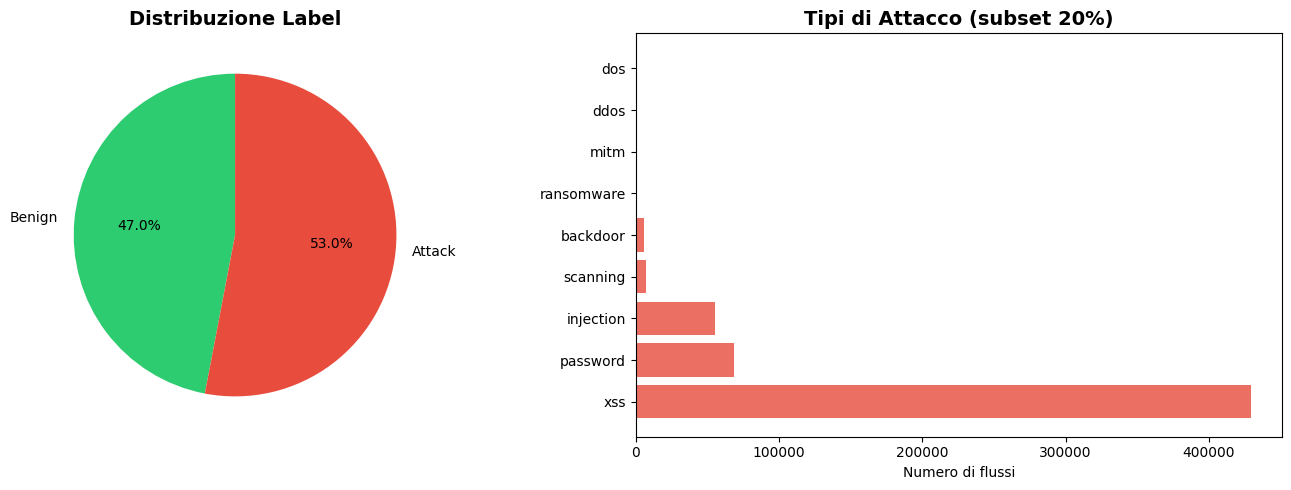

Figura salvata.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1 — Benign vs Attack
axes[0].pie(
    [benign_pct, attack_pct],
    labels=['Benign', 'Attack'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Distribuzione Label', fontsize=14, fontweight='bold')

# Grafico 2 — Tipi di attacco
attack_counts = df_subset[df_subset['Label']==1]['Attack'].value_counts()
axes[1].barh(
    attack_counts.index,
    attack_counts.values,
    color='#e74c3c',
    alpha=0.8
)
axes[1].set_title('Tipi di Attacco (subset 20%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Numero di flussi')

plt.tight_layout()
plt.savefig('../outputs/figures/attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata.")

Distribuzione temporale del traffico

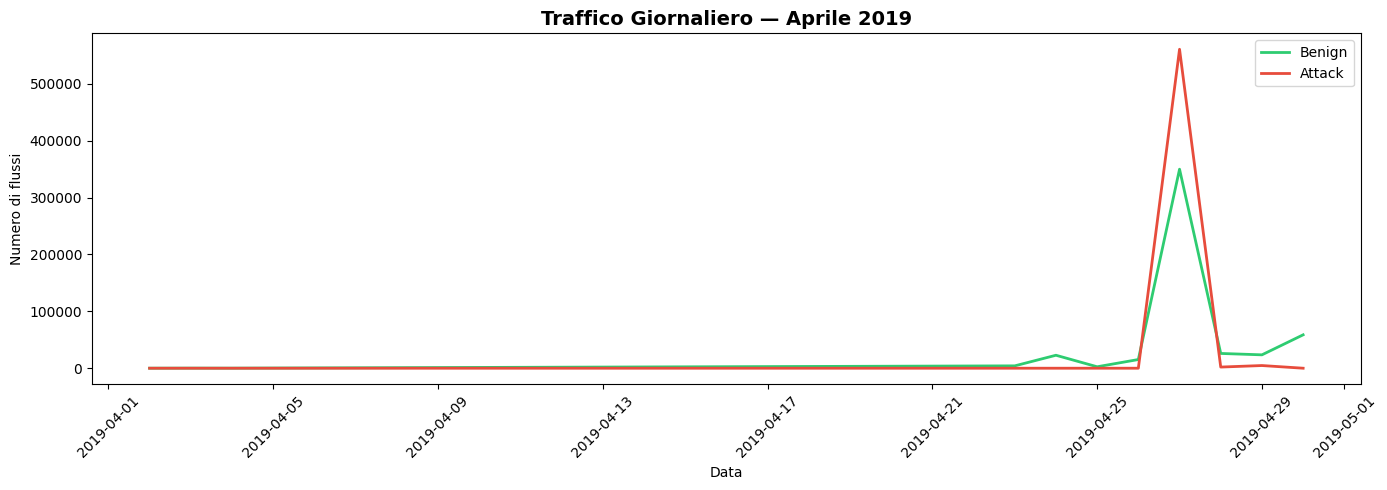

Figura salvata.


In [7]:
# Traffico per giorno
df_subset['Date'] = df_subset['Timestamp'].dt.date

daily = df_subset.groupby(['Date', 'Label_str']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))

daily['Benign'].plot(ax=ax, color='#2ecc71', label='Benign', linewidth=2)
daily['Attack'].plot(ax=ax, color='#e74c3c', label='Attack', linewidth=2)

ax.set_title('Traffico Giornaliero — Aprile 2019', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Numero di flussi')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/traffic_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salvata.")

Analisi delle feature principali

In [8]:
# Feature numeriche principali
feature_cols = [
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean',
    'Flow Byts/s', 'Flow Pkts/s'
]

print("=== STATISTICHE PER LABEL ===")
print(df_subset.groupby('Label_str')[feature_cols].mean().round(2).T)

=== STATISTICHE PER LABEL ===
Label_str             Attack      Benign
Flow Duration     1475499.00  8544194.45
Tot Fwd Pkts            4.20        9.61
Tot Bwd Pkts            3.07        4.64
Fwd Pkt Len Mean      167.22       47.90
Bwd Pkt Len Mean      206.15       79.84
Flow Byts/s        206990.36   190434.10
Flow Pkts/s         14333.83         inf


Network Topology

In [9]:
print("IP SORGENTI UNICI")
print(f"Totale: {df_subset['Src IP'].nunique()}")

print("\n IP DESTINAZIONE UNICI")
print(f"Totale: {df_subset['Dst IP'].nunique()}")

print("\nTOP 10 IP SORGENTI")
print(df_subset['Src IP'].value_counts().head(10))

print("\nTOP 10 IP DESTINAZIONE")
print(df_subset['Dst IP'].value_counts().head(10))

print("\n PROTOCOLLI")
print(df_subset['Protocol'].value_counts())

IP SORGENTI UNICI
Totale: 67124

 IP DESTINAZIONE UNICI
Totale: 1094

TOP 10 IP SORGENTI
Src IP
192.168.1.35      261047
192.168.1.39      165448
192.168.1.195      87107
176.28.50.165      85006
192.168.1.190      84781
192.168.1.32       74537
192.168.1.36       66561
192.168.1.152      58115
52.28.231.150      26602
18.194.169.124     26392
Name: count, dtype: int64

TOP 10 IP DESTINAZIONE
Dst IP
192.168.1.195     181046
192.168.1.35      152810
192.168.1.1       148304
192.168.1.39      103991
192.168.1.152      84796
192.168.1.190      65811
176.28.50.165      44282
192.168.1.32       43435
18.194.169.124     37318
52.28.231.150      36983
Name: count, dtype: int64

 PROTOCOLLI
Protocol
6     824622
17    138495
0     107235
Name: count, dtype: int64


Controllo sul funzionamento di utils.py

In [10]:
import importlib
import sys

# Rimuovi cache del modulo
if 'utils' in sys.modules:
    del sys.modules['utils']

sys.path.append('../src')

from utils import load_dataset, print_dataset_summary

df_check = load_dataset('../data/ton_iot_20pct.csv')
print_dataset_summary(df_check)

Righe totali:      1,070,352
Colonne:           86
IP sorgenti unici: 67,124
IP dest unici:     1,094
Periodo:           2019-04-02 19:58:04 → 2019-04-30 00:45:55

Label distribution:
Label_str
Attack    567305
Benign    503047
Name: count, dtype: int64


Grado dei Nodi

In [13]:
import networkx as nx
import pandas as pd
from utils import build_graph, WINDOW_HOURS

# Prendi una finestra con molto traffico
df['window'] = df['Timestamp'].dt.floor(f'{WINDOW_HOURS}h')
window_counts = df.groupby('window').size()
valid_windows = window_counts[window_counts >= 100].index
busy_window = valid_windows[34]

window_df = df[df['window'] == busy_window].copy()

G = build_graph(window_df, edge_types=['comm'])

# Calcola gradi
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

deg_df = pd.DataFrame({
    'ip': list(in_deg.keys()),
    'in_degree': list(in_deg.values()),
    'out_degree': list(out_deg.values()),
})
deg_df['total_degree'] = deg_df['in_degree'] + deg_df['out_degree']
deg_df = deg_df.sort_values('total_degree', ascending=False)

print("=== TOP 10 NODI PER GRADO TOTALE ===")
print(deg_df.head(10).to_string(index=False))

=== TOP 10 NODI PER GRADO TOTALE ===
             ip  in_degree  out_degree  total_degree
   1.32.192.168        586           0           586
  1.195.192.168        539           0           539
  1.152.192.168        174           0           174
  1.190.192.168        144           1           145
182.141.192.168          0          45            45
    1.1.192.168         45           0            45
182.140.192.168          0          44            44
182.179.192.168          0          40            40
  177.30.87.144          0          38            38
    192.168.1.1         38           0            38


In [15]:
# Per ogni nodo calcola: grado totale e percentuale di archi anomali
node_stats = {}

for node in G.nodes():
    out_edges = list(G.out_edges(node, data=True))
    in_edges  = list(G.in_edges(node, data=True))
    
    total = len(out_edges) + len(in_edges)
    anomalies = sum(1 for u,v,d in out_edges + in_edges if d.get('label')==1)
    
    node_stats[node] = {
        'in_degree':    len(in_edges),
        'out_degree':   len(out_edges),
        'total_degree': total,
        'anomaly_count': anomalies,
        'anomaly_rate': anomalies / total if total > 0 else 0
    }

stats_df = pd.DataFrame(node_stats).T
stats_df = stats_df.sort_values('total_degree', ascending=False)

print("=== TOP 10 NODI PER GRADO ===")
print(stats_df.head(10).round(3).to_string())

print("\n=== TOP 10 NODI PER ANOMALY RATE ===")
print(stats_df[stats_df['total_degree'] > 5]
      .sort_values('anomaly_rate', ascending=False)
      .head(10).round(3).to_string())

=== TOP 10 NODI PER GRADO ===
                 in_degree  out_degree  total_degree  anomaly_count  anomaly_rate
1.32.192.168         586.0         0.0         586.0            0.0           0.0
1.195.192.168        539.0         0.0         539.0            0.0           0.0
1.152.192.168        174.0         0.0         174.0            0.0           0.0
1.190.192.168        144.0         1.0         145.0            0.0           0.0
182.141.192.168        0.0        45.0          45.0            0.0           0.0
1.1.192.168           45.0         0.0          45.0            0.0           0.0
182.140.192.168        0.0        44.0          44.0            0.0           0.0
182.179.192.168        0.0        40.0          40.0            0.0           0.0
177.30.87.144          0.0        38.0          38.0            0.0           0.0
192.168.1.1           38.0         0.0          38.0            0.0           0.0

=== TOP 10 NODI PER ANOMALY RATE ===
                 in_degree  ou